
# Install dependencies


In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib tensorflow keras-tuner

#Imports & Mount Google Drive

In [ ]:
import os, zipfile, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Directory to save checkpoints
CHECKPOINT_DIR = "/content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
start_epoch = 1  # reset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# --- ADD HERE: HELPER FUNCTIONS FOR SIAMESE PREPROCESSING ---
def pad_or_trim_sequence(seq, target_len):
    """Trim or pad a 1D sequence to target_len"""
    if len(seq) > target_len:
        return seq[:target_len]
    elif len(seq) < target_len:
        # pad with zeros at the end
        return np.pad(seq, (0, target_len - len(seq)))
    else:
        return seq

def prepare_siamese_inputs(X_multi_raw, window_sizes):
    """
    X_multi_raw: list of raw arrays for each branch
    window_sizes: list of window sizes for each branch
    Returns list of arrays ready for model
    """
    X_multi = []
    for i, w in enumerate(window_sizes):
        X_branch = np.array([pad_or_trim_sequence(sample, w) for sample in X_multi_raw[i]])
        # add channel dimension
        X_multi.append(X_branch[..., None].astype(np.float32))
    return X_multi

# TRANSFORMER ENCODER

#Download NAB Dataset

In [ ]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
nab_zip_path = os.path.join(DATA_DIR, "nab.zip")
nab_url = "https://github.com/numenta/NAB/archive/refs/heads/master.zip"

if not os.path.exists(nab_zip_path):
    print("Downloading NAB dataset...")
    urllib.request.urlretrieve(nab_url, nab_zip_path)

nab_root = os.path.join(DATA_DIR, "NAB-master")
if not os.path.exists(nab_root):
    print("Unzipping...")
    with zipfile.ZipFile(nab_zip_path, 'r') as z:
        z.extractall(DATA_DIR)

csv_path = os.path.join(nab_root, "data", "realTraffic", "speed_6005.csv")
json_label_path = os.path.join(nab_root, "labels", "combined_labels.json")

#Load & preprocess CSV

In [ ]:
df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["value"] = df["value"].interpolate(method="time", limit_direction="both").fillna(method="ffill").fillna(method="bfill")

scaler = StandardScaler()
df["value_scaled"] = scaler.fit_transform(df[["value"]])

/tmp/ipykernel_12590/2120350521.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["value"] = df["value"].interpolate(method="time", limit_direction="both").fillna(method="ffill").fillna(method="bfill")


# Load Labels FIRST

In [ ]:
# Load combined_labels.json properly
with open(json_label_path, "r") as f:
    label_json = json.load(f)

print("Keys inside label file:")
print(list(label_json.keys())[:10])

Keys inside label file:
['artificialNoAnomaly/art_daily_no_noise.csv', 'artificialNoAnomaly/art_daily_perfect_square_wave.csv', 'artificialNoAnomaly/art_daily_small_noise.csv', 'artificialNoAnomaly/art_flatline.csv', 'artificialNoAnomaly/art_noisy.csv', 'artificialWithAnomaly/art_daily_flatmiddle.csv', 'artificialWithAnomaly/art_daily_jumpsdown.csv', 'artificialWithAnomaly/art_daily_jumpsup.csv', 'artificialWithAnomaly/art_daily_nojump.csv', 'artificialWithAnomaly/art_increase_spike_density.csv']


In [ ]:
print("Entries for this file:")
print(label_json.get("realTraffic/speed_6005.csv"))

Entries for this file:
['2015-09-17 07:00:00']


#Load NAB anomaly labels

In [ ]:
# Load labels first
with open(json_label_path, "r") as f:
    label_json = json.load(f)

anomaly_entries = label_json.get("realTraffic/speed_6005.csv", [])

# Create anomaly column
df["is_anomaly"] = 0
for entry in anomaly_entries:
    ts = pd.to_datetime(entry)
    idx = (df["timestamp"] - ts).abs().idxmin()
    df.loc[idx, "is_anomaly"] = 1

print("Number of anomaly timestamps in JSON:", len(anomaly_entries))
print("Anomaly indices in df:", df.index[df['is_anomaly']==1].tolist())
print("Total anomaly points in dataframe:", df["is_anomaly"].sum())

Number of anomaly timestamps in JSON: 1
Anomaly indices in df: [2386]
Total anomaly points in dataframe: 1


# Multi Scale sliding windows

In [ ]:

# Adaptive multi-scale windowing
def make_multi_scale_windows(series, min_windows=10):
    """
    Automatically choose window sizes and step based on series length.
    Ensures enough windows for short datasets and reasonable memory for long series.
    """
    N = len(series)

    # Base window sizes (as ratio of series length)
    w1 = max(10, min(50, N//20))
    w2 = max(w1+10, min(100, N//10))
    w3 = max(w2+10, min(150, N//5))

    WINDOW_SIZES = [w1, w2, w3]

    # Step proportional to window size, ensures enough windows
    STEP = max(1, min(5, N // (min_windows*len(WINDOW_SIZES))))

    X_multi = []
    for w in WINDOW_SIZES:
        X_w = []
        for start in range(0, N - w + 1, STEP):
            X_w.append(series[start:start+w])
        X_multi.append(np.array(X_w))

    # Align lengths
    min_len = min(len(x) for x in X_multi)
    X_multi = [x[:min_len] for x in X_multi]

    return X_multi, WINDOW_SIZES, STEP

series = df["value_scaled"].values.astype(np.float32)
X_multi, WINDOW_SIZES, STEP = make_multi_scale_windows(series, min_windows=10)




# Align lengths
min_len = min(len(x) for x in X_multi)
X_multi = [x[:min_len] for x in X_multi]

# Window-level labels
def make_window_labels(df, window_size, step):
    """
    Generate window-level anomaly labels.
    A window is labeled 1 if **any point in the window is anomalous**.
    """
    y = []
    anomaly_series = df["is_anomaly"].values
    for start in range(0, len(anomaly_series) - window_size + 1, step):
        window = anomaly_series[start : start + window_size]
        y.append(int(window.sum() > 0))  # 1 if any anomaly present
    return np.array(y)

# Labels (use largest window)
max_window = max(WINDOW_SIZES)  # largest window in multi-scale
Y = make_window_labels(df, window_size=max_window, step=STEP)

# Truncate to smallest window array length
min_len = min(len(x) for x in X_multi)
Y = Y[:min_len]


# Split
train_end = int(min_len*0.7)
val_end   = int(min_len*0.85)

X_train_multi = [x[:train_end] for x in X_multi]
X_val_multi   = [x[train_end:val_end] for x in X_multi]
X_test_multi  = [x[val_end:] for x in X_multi]

Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

# Prepare X_train_multi, X_val_multi, X_test_multi for flexible lengths
X_train_multi = prepare_siamese_inputs(X_train_multi, WINDOW_SIZES)
X_val_multi   = prepare_siamese_inputs(X_val_multi, WINDOW_SIZES)
X_test_multi  = prepare_siamese_inputs(X_test_multi, WINDOW_SIZES)

# Create y

In [ ]:


print("Total window anomalies:", Y.sum())

def generate_synthetic_anomalies(X_multi, fraction=0.05, noise_std=0.05):
    """
    X_multi: list of [num_windows, timesteps] arrays
    fraction: fraction of normal windows to perturb
    Returns: X_multi with synthetic anomalies appended
    """
    n_windows = X_multi[0].shape[0]
    n_synth = max(1, int(fraction * n_windows))

    synth_multi = []
    for x in X_multi:
        idx = np.random.choice(n_windows, n_synth, replace=False)
        x_synth = x[idx].copy()
        # Add noise spikes
        x_synth += np.random.normal(0, noise_std, x_synth.shape)
        synth_multi.append(x_synth)

    return synth_multi, n_synth

# --- Generate synthetic anomalies for Siamese training ---
X_synth, n_synth = generate_synthetic_anomalies(X_train_multi, fraction=0.05, noise_std=0.05)

# Append synthetic anomalies to training windows
X_train_multi = [np.concatenate([X_train_multi[i], X_synth[i]], axis=0) for i in range(len(X_train_multi))]

# Label them as NORMAL
Y_train = np.concatenate([Y_train, np.zeros(n_synth, dtype=int)])

print("Updated Y_train shape with synthetic anomalies:", Y_train.shape)
print("Number of synthetic anomalies added:", n_synth)

Total window anomalies: 23
Updated Y_train shape with synthetic anomalies: (345,)
Number of synthetic anomalies added: 16


# Build Masked Autoencoder

In [ ]:
# --- Data Augmentation Function (Safe) ---
def augment_windows(x, noise_std=0.005, scale_range=(0.95, 1.05)):
    """
    Adds Gaussian noise and random scaling to normal windows.
    Accepts 2D or 3D input, ignores extra singleton dims.
    x: [batch, timesteps, channels]
    """
    x = tf.convert_to_tensor(x)

    # Remove extra singleton dims at the end
    while len(x.shape) > 3:
        x = tf.squeeze(x, axis=-1)

    # If x is 2D (batch, timesteps), add channel dim
    if len(x.shape) == 2:
        x = tf.expand_dims(x, -1)

    # If no windows, return as-is
    if tf.shape(x)[0] == 0:
        return x

    # Gaussian noise
    x_noisy = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=noise_std)

    # Random scaling per window
    scales = tf.random.uniform([tf.shape(x)[0], 1, 1], scale_range[0], scale_range[1])

    return x_noisy * scales
# --- Masking Function ---
def apply_random_mask(x, mask_ratio=0.1):
    b = tf.shape(x)[0]
    t = tf.shape(x)[1]
    mask = tf.cast(tf.random.uniform((b, t), 0, 1) < mask_ratio, tf.float32)
    x_masked = x * tf.expand_dims(1 - mask, -1)
    return x_masked, tf.expand_dims(mask, -1)

# ===========================
# Apply augmentation + masking safely
# ===========================
for i in range(len(X_train_multi)):

    # Convert to tensor, keep channel dim 3D
    x = tf.convert_to_tensor(X_train_multi[i])
    if len(x.shape) == 2:
        x = tf.expand_dims(x, -1)  # shape: [batch, timesteps, 1]

    normal_idx = tf.where(Y_train == 0)[:, 0]

    if tf.size(normal_idx) > 0:
        x_normal = tf.gather(x, normal_idx)
        x_aug = augment_windows(x_normal)  # now safe even if shape was 4D
        x = tf.tensor_scatter_nd_update(x, tf.expand_dims(normal_idx, 1), x_aug)

    x, _ = apply_random_mask(x, mask_ratio=0.1)

    X_train_multi[i] = x.numpy()

# Prepare datasets for training

In [ ]:
BATCH_SIZE = 64

# Train Masked Autoencoder with checkpoints

In [ ]:
import re
EPOCHS = 40
best_val = 1e9
patience = 3
wait = 0
start_epoch = 1


# Find latest checkpoint
latest_ae_ckpt = None
latest_epoch = 0

files = sorted(os.listdir(CHECKPOINT_DIR))
for f in reversed(files):
    if f.startswith("siamese_epoch") and f.endswith(".keras"):
        latest_ae_ckpt = os.path.join(CHECKPOINT_DIR, f)
        # Extract epoch number from filename if you saved as 'siamese_epochXX.keras'
        m = re.search(r'(\d+)', f)
        if m:
            latest_epoch = int(m.group(1))
        break

if latest_ae_ckpt:
    print(f"Resuming Siamese from: {latest_ae_ckpt}")
    optimizer = keras.optimizers.Adam(1e-4)  # keep your original LR
    start_epoch = latest_epoch + 1

# Prepare Support & Query Embeddings
# Remove Precomputed Embeddings

In [ ]:
# -----------------------------
# 6. SIAMESE MODEL (MULTI INPUT) FIXED
# -----------------------------

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

# --- Attention fusion as a Layer ---
class AttentionFusion(layers.Layer):
    def __init__(self, dim=None, **kwargs):
        super().__init__(**kwargs)
        # Create Dense layer here once
        self.dense = layers.Dense(1, activation="tanh")

    def call(self, embs):
        # embs: list of [batch, dim]
        x = tf.stack(embs, axis=1)  # [batch, scales, dim]
        weights = self.dense(x)      # [batch, scales, 1]
        weights = tf.nn.softmax(weights, axis=1)  # normalize across scales
        fused = tf.reduce_sum(weights * x, axis=1)  # weighted sum
        return fused

# --- Multi-scale encoder as a Layer ---
class MultiScaleEncoder(layers.Layer):
    def __init__(self, encoders, **kwargs):
        super().__init__(**kwargs)
        self.encoders = encoders
        self.attn = AttentionFusion()

    def call(self, inputs):
        embs = [enc(inputs[i]) for i, enc in enumerate(self.encoders)]
        return self.attn(embs)

# --- Prototype Layer ---
class PrototypeLayer(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.prototype = self.add_weight(
            shape=(dim,),
            initializer="random_normal",
            trainable=True,
            name="prototype"
        )

    def call(self, x):
        return self.prototype

# --- Build Encoder ---
def build_encoder(T):
    inputs = keras.Input(shape=(T, 1))

    x = layers.Dense(128)(inputs)

    # Positional embedding
    pos_emb_layer = layers.Embedding(input_dim=1000, output_dim=128)
    pos = tf.range(start=0, limit=T, delta=1)
    pos_emb = pos_emb_layer(pos)
    pos_emb = tf.expand_dims(pos_emb, axis=0)
    x = x + pos_emb

    # Transformer block
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ffn = layers.Dense(128, activation="relu")(x)
    ffn = layers.Dense(128)(ffn)
    x = layers.LayerNormalization()(x + ffn)

    # Global pooling + L2 normalization
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(x)

    return keras.Model(inputs, x)

# --- Build encoders for all window sizes ---
WINDOW_SIZES = WINDOW_SIZES  # example, replace with your actual sizes
encoders = [build_encoder(w) for w in WINDOW_SIZES]

# --- Instantiate multi-scale encoder ---
multi_encoder = MultiScaleEncoder(encoders)

# --- Dummy input to get embedding dim ---
dummy_input = [np.zeros((1, w, 1)) for w in WINDOW_SIZES]
embedding_dim = multi_encoder(dummy_input).shape[-1]

# --- Instantiate prototype layer ---
proto_layer = PrototypeLayer(embedding_dim)

# Load saved prototype if exists
if os.path.exists("prototype.npy"):
    print("Loading saved prototype into proto_layer...")
    proto_layer.prototype.assign(np.load("prototype.npy"))

# --- Build Siamese inputs (3 branches) ---
inputs_a = [Input(shape=(w, 1)) for w in WINDOW_SIZES]
inputs_p = [Input(shape=(w, 1)) for w in WINDOW_SIZES]
inputs_n = [Input(shape=(w, 1)) for w in WINDOW_SIZES]



# Encode each branch
emb_a = multi_encoder(inputs_a)
emb_p = multi_encoder(inputs_p)
emb_n = multi_encoder(inputs_n)

# Concatenate embeddings for triplet loss
output = layers.Concatenate()([emb_a, emb_p, emb_n])

siamese = Model(inputs=inputs_a + inputs_p + inputs_n, outputs=output, name="siamese_multi_input")

# ⚠️ Create a new optimizer here
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

siamese.compile(
    optimizer=optimizer,
    loss=triplet_loss_with_prototype()
)

# Attach prototype layer to model for checkpoint saving
siamese.proto_layer = proto_layer

# --- Optional utility function for numpy inputs ---
def get_siamese_embeddings(X_multi):
    inputs = [X_multi[i][..., None].astype(np.float32) for i in range(len(WINDOW_SIZES))]
    return multi_encoder(inputs).numpy()

In [ ]:
# ==========================================
# DO NOT PRECOMPUTE EMBEDDINGS
# We train Siamese end-to-end
# ==========================================

print("Preparing Siamese training data (raw windows)...")

normal_idx = np.where(Y_train == 0)[0]
anomaly_idx = np.where(Y_train == 1)[0]

print("Normal samples:", len(normal_idx))
print("Anomaly samples:", len(anomaly_idx))

Preparing Siamese training data (raw windows)...
Normal samples: 345
Anomaly samples: 0


In [ ]:
print(np.unique(Y_train, return_counts=True))
print(np.unique(Y_val, return_counts=True))
print(np.unique(Y_test, return_counts=True))

(array([0]), array([345]))
(array([0]), array([71]))
(array([0, 1]), array([48, 23]))


In [ ]:

print("Total anomaly windows:", Y.sum())
print("Train window anomaly count:", Y_train.sum())
print("Val window anomaly count:", Y_val.sum())
print("Test window anomaly count:", Y_test.sum())

Total anomaly windows: 23
Train window anomaly count: 0
Val window anomaly count: 0
Test window anomaly count: 23


# Proper Triplet Generator (RAW INPUT, Not Embeddings)

# REAL Hybrid Siamese (Uses Encoder Inside)

In [ ]:
from tensorflow.keras.layers import Lambda

# Correct Triplet Loss

In [ ]:
dummy_input = [np.zeros((1, w, 1)) for w in WINDOW_SIZES]
embedding_dim = multi_encoder(dummy_input).shape[-1]

class PrototypeLayer(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.prototype = self.add_weight(
            shape=(dim,),
            initializer="random_normal",
            trainable=True,
            name="prototype"
        )

    def call(self, x):
        return self.prototype

proto_layer = PrototypeLayer(embedding_dim)

# Load saved prototype if exists
if os.path.exists("prototype.npy"):
    print("Loading saved prototype into proto_layer...")
    proto_layer.prototype.assign(np.load("prototype.npy"))

def triplet_loss_with_prototype(margin=0.6, lambda_proto=0.1):

    def loss(y_true, y_pred):

        dim = y_pred.shape[1] // 3

        a = y_pred[:, :dim]
        p = y_pred[:, dim:2*dim]
        n = y_pred[:, 2*dim:]

        pos = tf.reduce_sum(tf.square(a - p), axis=1)
        neg = tf.reduce_sum(tf.square(a - n), axis=1)

        triplet = tf.maximum(pos - neg + margin, 0.0)

        #  Prototype loss (NEW)
        proto = proto_layer.prototype
        proto_norm = tf.nn.l2_normalize(proto, axis=0)
        proto_loss = tf.reduce_sum(tf.square(a - proto_norm), axis=1)

        return tf.reduce_mean(triplet + lambda_proto * proto_loss)

    return loss

if 'optimizer' not in globals():
    optimizer = keras.optimizers.Adam(1e-4)

siamese.compile(
    optimizer=optimizer,
    loss=triplet_loss_with_prototype()
)

# Train Siamese Properly

In [ ]:
# =========================
# TRAIN SIAMESE MODEL (CORRECTED)
# =========================

BATCH_SIZE = 64
EPOCHS = 40
WARMUP_EPOCHS = 5
patience = 8
best_val = np.inf
wait = 0

# Check latest checkpoint
latest_ckpt = None
latest_epoch = 0
files = sorted(os.listdir(CHECKPOINT_DIR))
for f in reversed(files):
    if f.startswith("siamese_epoch") and f.endswith(".h5"):
        latest_ckpt = os.path.join(CHECKPOINT_DIR, f)
        m = re.search(r'siamese_epoch(\d+)_best\.h5', f)
        if m:
            latest_epoch = int(m.group(1))
        break

start_epoch = latest_epoch + 1
if latest_ckpt:
    print(f"Resuming from checkpoint: {latest_ckpt}")
    siamese.load_weights(latest_ckpt)

# Callbacks
triplet_ckpt_path = os.path.join(CHECKPOINT_DIR, "siamese_epoch{epoch:02d}_best.weights.h5")
triplet_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=triplet_ckpt_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    save_weights_only=True,
    verbose=1
)

# ===========================
# TRIPLET GENERATOR (WITH HARD NEGATIVE MINING)
# ===========================

def generate_triplets_multi_adaptive(X_multi, Y, num_triplets=5000, use_hard_neg=False):
    normal_idx = np.where(Y == 0)[0]
    anomaly_idx = np.where(Y == 1)[0]

    if len(normal_idx) < 2:
        return [], [], []

    A_multi = [[] for _ in range(len(X_multi))]
    P_multi = [[] for _ in range(len(X_multi))]
    N_multi = [[] for _ in range(len(X_multi))]

    # HARD NEGATIVE MINING
    if use_hard_neg:
        X_normal = [x[normal_idx] for x in X_multi]
        emb = get_siamese_embeddings(X_normal)

        proto = proto_layer.prototype.numpy()
        proto = proto / (np.linalg.norm(proto) + 1e-8)

        dist = np.linalg.norm(emb - proto, axis=1)
        thresh = np.percentile(dist, 90)
        hard_local_idx = np.where(dist >= thresh)[0]

        hard_idx = normal_idx[hard_local_idx]
    else:
        hard_idx = []

    # TRIPLET SAMPLING
    for _ in range(num_triplets):
        a_idx = np.random.choice(normal_idx)
        p_idx = np.random.choice(normal_idx)

        if use_hard_neg and len(hard_idx) > 0:
            n_idx = np.random.choice(hard_idx)
        else:
            n_idx = np.random.choice(anomaly_idx) if len(anomaly_idx) > 0 else np.random.choice(normal_idx)

        for i in range(len(X_multi)):
            A_multi[i].append(X_multi[i][a_idx])
            P_multi[i].append(X_multi[i][p_idx])
            N_multi[i].append(X_multi[i][n_idx])

    A_multi = [np.array(x) for x in A_multi]
    P_multi = [np.array(x) for x in P_multi]
    N_multi = [np.array(x) for x in N_multi]

    return A_multi, P_multi, N_multi

# --- TRAIN LOOP ---
for epoch in range(start_epoch, EPOCHS + 1):
    print(f"\n========== Epoch {epoch}/{EPOCHS} ==========")
    use_hard = epoch > WARMUP_EPOCHS
    print("Using HARD negatives" if use_hard else "Using RANDOM negatives (warm-up)")

    # Generate triplets
    A, P, N = generate_triplets_multi_adaptive(
        X_train_multi, Y_train,
        num_triplets=8000,
        use_hard_neg=use_hard
    )

    if len(A) == 0:
        print("No triplets generated, skipping epoch...")
        continue

    # Prepare inputs for model
    train_inputs = []
    for triplet in [A, P, N]:
        for i in range(len(WINDOW_SIZES)):
            x = triplet[i]
            if x.ndim == 2:
                x = x[..., None]  # add channel
            train_inputs.append(x.astype(np.float32))

    # Dummy labels
    Y_train_dummy = np.zeros(train_inputs[0].shape[0], dtype=np.float32)
    split = int(0.9 * len(A))
    train_data = [x[:split] for x in train_inputs]
    val_data   = [x[split:] for x in train_inputs]
    Y_train_split = Y_train_dummy[:split]
    Y_val_split   = Y_train_dummy[split:]

    for i, inp in enumerate(train_inputs):
        print(f"train_input[{i}].shape = {inp.shape}")

    # Fit one epoch
    history = siamese.fit(
        train_data,
        Y_train_split,
        batch_size=BATCH_SIZE,
        epochs=1,
        validation_data=(val_data, Y_val_split),
        callbacks=[triplet_checkpoint_cb],
        verbose=1
    )

    # Early stopping
    current_val = history.history['val_loss'][-1]
    if current_val < best_val:
        best_val = current_val
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered!")
            break

# Save final model weights
siamese.save_weights("final_model_weights.weights.h5")
np.save("prototype.npy", proto_layer.prototype.numpy())
print("Model saved successfully!")

Resuming from checkpoint: /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_epoch01_best.weights.h5

========== Epoch 1/40 ==========
Using RANDOM negatives (warm-up)
train_input[0].shape = (8000, 50, 1)
train_input[1].shape = (8000, 100, 1)
train_input[2].shape = (8000, 150, 1)
train_input[3].shape = (8000, 50, 1)
train_input[4].shape = (8000, 100, 1)
train_input[5].shape = (8000, 150, 1)
train_input[6].shape = (8000, 50, 1)
train_input[7].shape = (8000, 100, 1)
train_input[8].shape = (8000, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0150
Epoch 1: val_loss improved from None to 0.64393, saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_epoch01_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_epoch01_best.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0150 - val_loss: 0.6439

========== Epoch 2/40 ==========
Using RANDOM negatives (warm-up)
train_in

# FEW-SHOT PROTOTYPE ANOMALY SCORING (REAL HYBRID)

# Correct Threshold (Only Normal Validation)

# Evaluate

In [ ]:
# ==========================================
# SAFE EVALUATION & METRICS
# ==========================================




# Compute embeddings
train_emb = get_siamese_embeddings(X_train_multi)
val_emb   = get_siamese_embeddings(X_val_multi)
test_emb  = get_siamese_embeddings(X_test_multi)


# BASELINE: Isolation Forest (for paper comparison)
from sklearn.ensemble import IsolationForest

contamination = max(0.01, Y_train.mean())
# Try setting a fixed contamination
iso = IsolationForest(contamination=0.3, random_state=42)
iso.fit(train_emb)

iso_pred = iso.predict(test_emb)
iso_pred = (iso_pred == -1).astype(int)

# Metrics
print("Isolation Forest Precision:", precision_score(Y_test, iso_pred))
print("Isolation Forest Recall:", recall_score(Y_test, iso_pred))
print("Isolation Forest F1:", f1_score(Y_test, iso_pred))
print("Isolation Forest Confusion Matrix:\n", confusion_matrix(Y_test, iso_pred))

# Compute distance of each embedding to normal prototype
proto_np = proto_layer.prototype.numpy()
proto_np = proto_np / (np.linalg.norm(proto_np) + 1e-8)

train_scores = np.linalg.norm(train_emb - proto_np, axis=1)
val_scores   = np.linalg.norm(val_emb - proto_np, axis=1)
test_scores  = np.linalg.norm(test_emb - proto_np, axis=1)

# Threshold based on 90th percentile of normal validation windows
if np.sum(Y_val==0) < 5:
    mu = np.mean(val_scores)
    sigma = np.std(val_scores)
else:
    mu = np.mean(val_scores[Y_val==0])
    sigma = np.std(val_scores[Y_val==0])


k_values = [1.5, 2, 2.5, 3]
best_f1 = 0
threshold = mu + k_values[0]*sigma
for k in k_values:
    th = mu + k * sigma
    preds = (val_scores > th).astype(int)
    f1 = f1_score(Y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        threshold = th

print(f"Best Threshold (μ + kσ): {threshold}")

# Predict anomalies
predictions = (test_scores > threshold).astype(int)

# Make sure shapes match
assert len(predictions) == len(Y_test), f"Shape mismatch: {len(predictions)} vs {len(Y_test)}"

# Compute metrics
precision = precision_score(Y_test, predictions)
recall    = recall_score(Y_test, predictions)
f1        = f1_score(Y_test, predictions)
conf_matrix = confusion_matrix(Y_test, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)



Isolation Forest Precision: 0.6388888888888888
Isolation Forest Recall: 1.0
Isolation Forest F1: 0.7796610169491526
Isolation Forest Confusion Matrix:
 [[35 13]
 [ 0 23]]
Best Threshold (μ + kσ): 0.5057613253593445
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Confusion Matrix:
 [[48  0]
 [ 0 23]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Plot

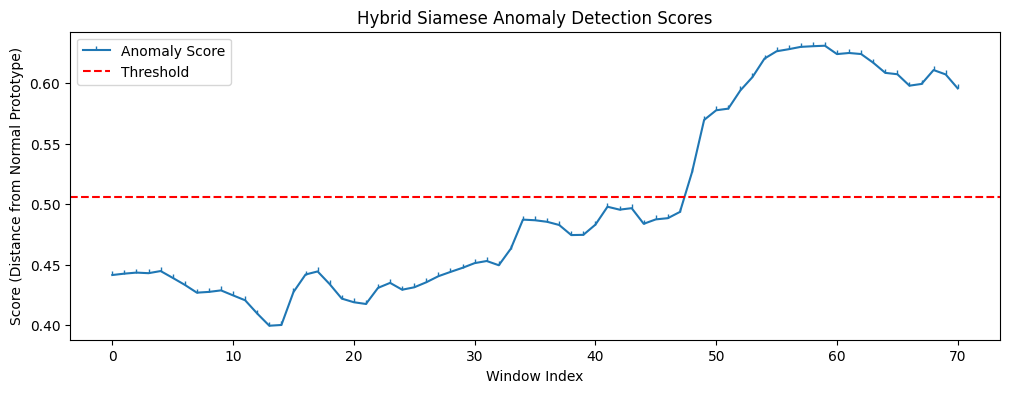

In [ ]:
# ==========================================
# Plot anomaly scores
# ==========================================
plt.figure(figsize=(12,4))
plt.plot(test_scores, label="Anomaly Score", marker=2, markersize=3)
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.title("Hybrid Siamese Anomaly Detection Scores")
plt.xlabel("Window Index")
plt.ylabel("Score (Distance from Normal Prototype)")
plt.legend()
plt.show()